# 5. Resultados de scikit-learn

Este capítulo consolida las seis ejecuciones sobre la misma prueba común. Las métricas de clasificación usan el umbral predeterminado de cada modelo: 0,5 para probabilidades y 0 para `decision_function` de `LinearSVC`. El AUC utiliza la puntuación continua y no depende de un umbral.

## 5.1 Modelos incluidos y qué aprende cada uno

| Modelo | Idea principal |
|:--|:--|
| Regresión logística | Combina las variables con pesos y transforma el resultado en una probabilidad de default. |
| Árbol de decisión | Divide sucesivamente los préstamos mediante reglas sobre variables, hasta formar grupos con resultados más parecidos. |
| Bosque aleatorio | Promedia muchos árboles entrenados con variaciones de filas y variables para reducir la inestabilidad de un árbol individual. |
| HistGradientBoosting | Construye árboles por etapas; cada nueva etapa corrige parte de los errores de las anteriores. |
| LinearSVC | Busca una frontera lineal que separe las clases con el mayor margen; su puntuación no es una probabilidad calibrada. |
| GaussianNB | Calcula la probabilidad de cada clase suponiendo distribuciones gaussianas y que las variables son condicionalmente independientes. |

`best_params` y `best_cv_auc` resumen la búsqueda sobre los datos de entrenamiento y sus folds. Las métricas de prueba se calculan después, sobre las filas reservadas; esa prueba no participa en la selección de parámetros.

`C` regula cuánto se penalizan los coeficientes en los modelos lineales: valores menores aplican una regularización más fuerte. `max_depth` limita cuántas decisiones puede encadenar un árbol; `n_estimators` indica cuántos árboles reúne el bosque; y `max_iter` fija las etapas del boosting. La validación cruzada elige entre los valores probados, no entre todos los posibles.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_DIR / 'results' / 'sklearn'
PRED_DIR = PROJECT_DIR / 'artifacts' / 'sklearn' / 'predictions'
FIGURES_DIR = PROJECT_DIR / 'figures' / 'sklearn'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model_names = [
    'logistic_regression', 'decision_tree', 'random_forest',
    'hist_gradient_boosting', 'linear_svc', 'gaussian_nb',
]
labels = {
    'logistic_regression': 'Regresión logística',
    'decision_tree': 'Árbol de decisión',
    'random_forest': 'Bosque aleatorio',
    'hist_gradient_boosting': 'HistGradientBoosting',
    'linear_svc': 'SVM lineal',
    'gaussian_nb': 'Naive Bayes gaussiano',
}

records = []
for model in model_names:
    with open(RESULTS_DIR / f'metrics_{model}.json', encoding='utf-8') as stream:
        record = json.load(stream)
    record['nombre'] = labels[model]
    records.append(record)

metrics = pd.DataFrame(records).set_index('model')
metrics = metrics[['nombre', 'implementation', 'best_params', 'best_cv_auc', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision', 'fit_cv_seconds', 'predict_seconds', 'tn', 'fp', 'fn', 'tp']]
display(metrics)
metrics.to_csv(RESULTS_DIR / 'comparacion_metricas_sklearn.csv', encoding='utf-8-sig')

,nombre,implementation,best_params,best_cv_auc,accuracy,precision,recall,f1,roc_auc,average_precision,fit_cv_seconds,predict_seconds,tn,fp,fn,tp
model,,,,,,,,,,,,,,,,
logistic_regression,Regresión logística,LogisticRegression,{'C': 0.9291538753149833},0.709859,0.802350,0.549241,0.055239,0.100382,0.709843,0.371344,18.726412,0.047442,212915,2435,50745,2967
decision_tree,Árbol de decisión,DecisionTreeClassifier,{'max_depth': 10},0.702833,0.801488,0.522098,0.065982,0.117157,0.703977,0.361099,571.605190,0.206016,212106,3244,50168,3544
random_forest,Bosque aleatorio,RandomForestClassifier,"{'max_depth': 15, 'n_estimators': 10}",0.707250,0.802020,0.548121,0.046973,0.086530,0.707964,0.368679,433.825688,1.927334,213270,2080,51189,2523
hist_gradient_boosting,HistGradientBoosting,HistGradientBoostingClassifier,"{'max_depth': 5, 'max_iter': 50}",0.712909,0.802804,0.574251,0.047084,0.087033,0.713237,0.377921,220.668085,11.312673,213475,1875,51183,2529
linear_svc,SVM lineal,LinearSVC,{'C': 0.009291538753149831},0.499399,0.800373,0.000000,0.000000,0.000000,0.475851,0.194947,894.187338,0.211500,215350,0,53712,0
gaussian_nb,Naive Bayes gaussiano,GaussianNB,{},NaN,0.669236,0.313332,0.551329,0.399576,0.666767,0.312205,2.586749,1.337401,150453,64897,24099,29613


La tabla reúne el mejor AUC de validación cruzada, las métricas en la prueba y los tiempos. `HistGradientBoosting` logra el AUC mayor (0,7132), seguido por regresión logística (0,7098) y bosque aleatorio (0,7080); las diferencias entre estos tres son pequeñas. `GaussianNB` alcanza un recall más alto (0,5513) pero menor precisión (0,3133) y AUC (0,6668): detecta más préstamos castigados a costa de marcar más préstamos pagados como riesgo. `LinearSVC` obtiene AUC de 0,4759 y, al umbral predeterminado, predice los 269.062 préstamos como pagados: su accuracy de 0,8004 solo refleja la clase mayoritaria y su recall es cero. El modelo con mayor AUC ordena mejor los casos en general, pero no necesariamente ofrece el mejor balance de errores al umbral usado.

El AUC es la métrica de selección solicitada y AUC-PR presta atención a la clase minoritaria. Como `Fully Paid` representa cerca de 80 % de los datos, la accuracy se interpreta junto con recall, F1 y la matriz de confusión.

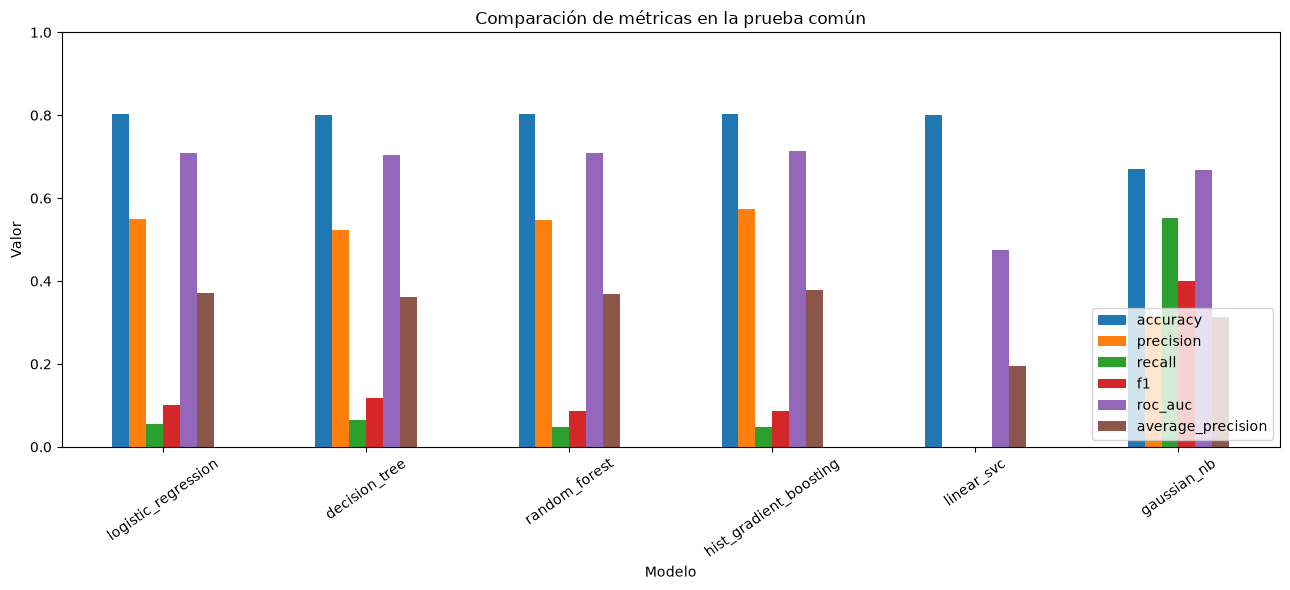

In [2]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']
fig, ax = plt.subplots(figsize=(13, 6))
metrics[metric_cols].plot(kind='bar', ax=ax)
ax.set_title('Comparación de métricas en la prueba común')
ax.set_ylabel('Valor')
ax.set_xlabel('Modelo')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'metricas_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

En el gráfico se comparan seis preguntas distintas: `accuracy` es la proporción de aciertos; `precision` indica qué proporción de las alertas de default eran correctas; `recall` mide cuántos defaults se detectaron; F1 resume el equilibrio entre precisión y recall; AUC ROC evalúa el ordenamiento para múltiples umbrales; y AUC-PR resume precisión y recall en la clase positiva. La altura de `accuracy` cercana a 0,80 no basta para escoger el modelo: con la prevalencia observada, un predictor que siempre diga “pagado” ya se acerca a ese valor.

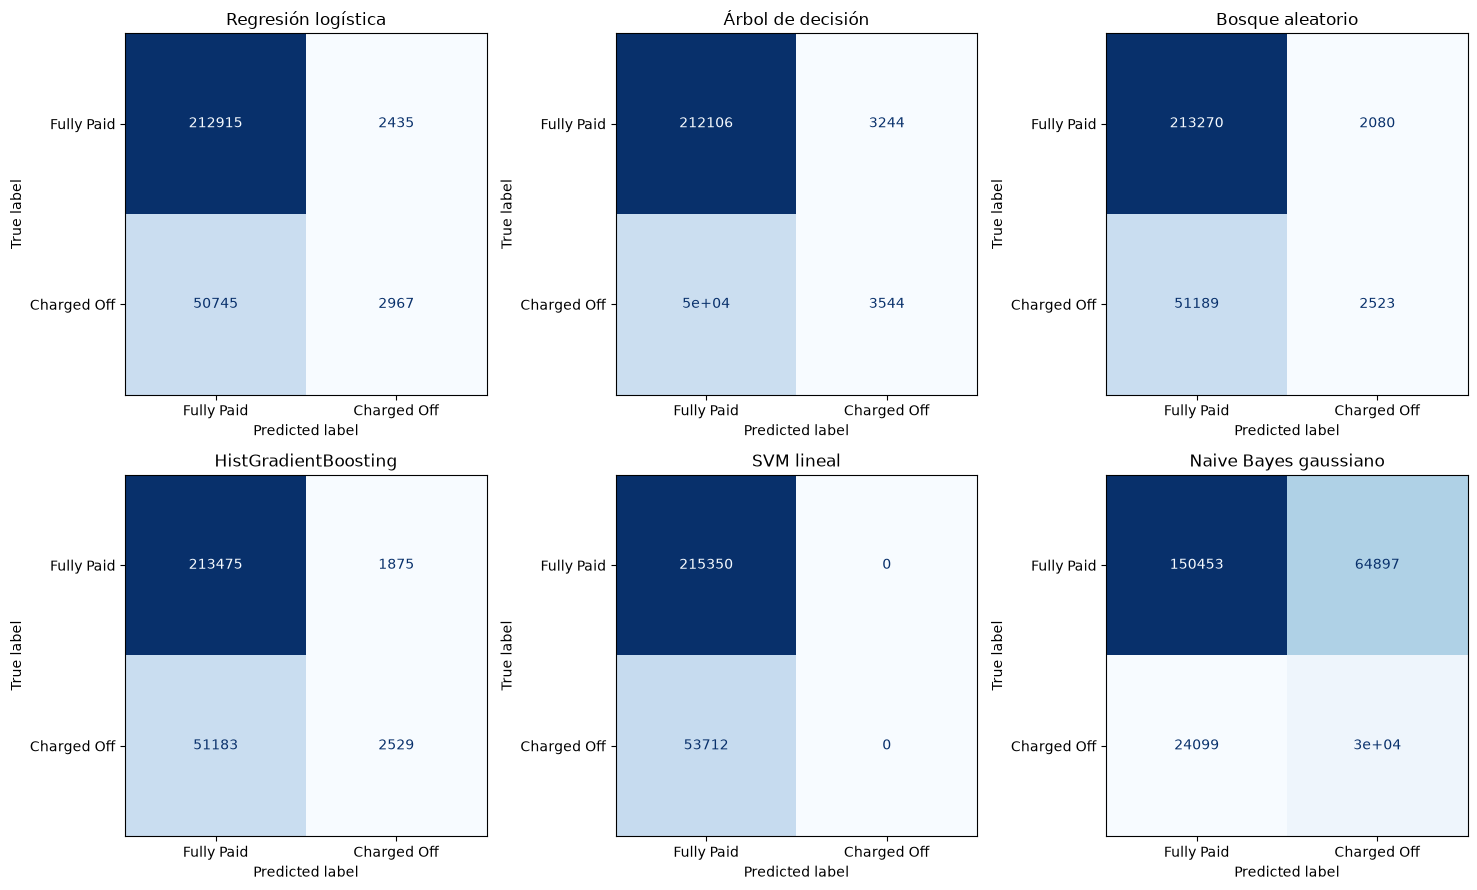

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, model in zip(axes.flat, model_names):
    pred = pd.read_parquet(PRED_DIR / f'test_{model}.parquet')
    ConfusionMatrixDisplay.from_predictions(
        pred['default'], pred['prediction'],
        display_labels=['Fully Paid', 'Charged Off'],
        cmap='Blues', colorbar=False, ax=ax,
    )
    ax.set_title(labels[model])
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'matrices_confusion_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

Las matrices muestran directamente los tipos de error. `HistGradientBoosting` detecta 2.529 de los 53.712 préstamos castigados de prueba (recall 4,7 %) y deja pasar 51.183. `GaussianNB` detecta 29.613 (recall 55,1 %), pero genera 64.897 falsas alarmas entre los préstamos pagados. `LinearSVC` clasifica todos como pagados. Estos resultados corresponden a los umbrales predeterminados; la decisión de umbral debe ajustarse según el costo relativo de dejar pasar un default frente a revisar un préstamo que sí se pagaría.

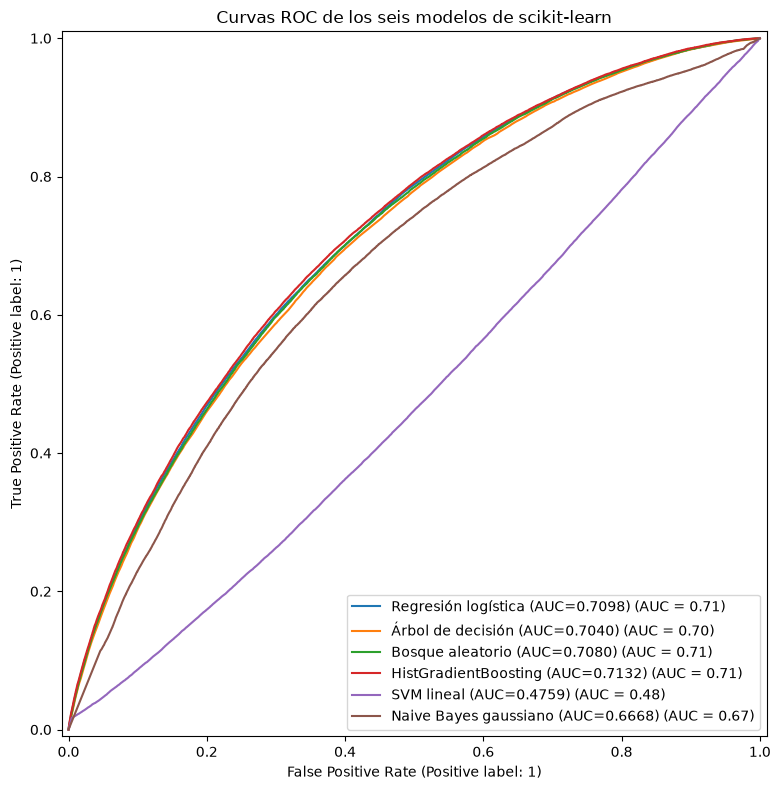

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
for model in model_names:
    pred = pd.read_parquet(PRED_DIR / f'test_{model}.parquet')
    RocCurveDisplay.from_predictions(
        pred['default'], pred['score'], name=f"{labels[model]} (AUC={metrics.loc[model, 'roc_auc']:.4f})", ax=ax
    )
ax.set_title('Curvas ROC de los seis modelos de scikit-learn')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'curvas_roc_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

Cada curva ROC representa la relación entre la tasa de verdaderos positivos y la de falsas alarmas al variar el umbral. Una curva más cercana a la esquina superior izquierda y con mayor AUC indica mejor capacidad de ordenar un préstamo castigado por encima de uno pagado. El gráfico explica por qué un modelo puede tener AUC razonable y recall muy bajo al umbral fijo: el ranking y el punto operativo son cuestiones diferentes.

In [5]:
timing = metrics[['fit_cv_seconds', 'predict_seconds']].copy()
timing['tiempo_total_segundos'] = timing.sum(axis=1)
timing['modelo'] = [labels[m] for m in timing.index]
display(timing.sort_values('tiempo_total_segundos'))
timing.to_csv(RESULTS_DIR / 'tiempos_sklearn.csv', encoding='utf-8-sig')

,fit_cv_seconds,predict_seconds,tiempo_total_segundos,modelo
model,,,,
gaussian_nb,2.586749,1.337401,3.924149,Naive Bayes gaussiano
logistic_regression,18.726412,0.047442,18.773854,Regresión logística
hist_gradient_boosting,220.668085,11.312673,231.980758,HistGradientBoosting
random_forest,433.825688,1.927334,435.753022,Bosque aleatorio
decision_tree,571.605190,0.206016,571.811207,Árbol de decisión
linear_svc,894.187338,0.211500,894.398838,SVM lineal


El tiempo total suma ajuste con validación cruzada y predicción en prueba, pero no incluye la lectura ni el preprocesamiento. `GaussianNB` fue el más rápido (3,9 s), mientras que `LinearSVC` tardó cerca de 894,4 s y el árbol 571,8 s. Estos valores dependen de los grids y del hardware local; sirven para dimensionar esta ejecución y se compararán con PySpark usando la misma definición de tiempo en el capítulo final.

## 5.2 Nota sobre equivalencia y costo computacional

La guía permite sustituir `GradientBoostingClassifier` por `HistGradientBoostingClassifier` cuando el costo sea prohibitivo con el dataset completo. Se documenta esa sustitución. Para el bosque se usaron 10 árboles y se compararon las profundidades 10 y 15, porque los ensayos con 50 árboles no fueron viables en el hardware disponible; esta decisión debe quedar explícita al interpretar la comparación con PySpark.